In [1]:
!pip install --upgrade torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 61.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import VOCDetection
#from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torchvision.transforms.v2 as T
import os





In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
model = torch.hub.load("facebookresearch/detr", "detr_resnet101", pretrained=True)
model.to(device)
model.eval()

Downloading: "https://github.com/facebookresearch/detr/zipball/main" to /root/.cache/torch/hub/main.zip
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:00<00:00, 182MB/s]
Downloading: "https://dl.fbaipublicfiles.com/detr/detr-r101-2c7b67e5.pth" to /root/.ca

DETR(
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (decoder): TransformerDecoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerDecoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, ou

In [5]:
COCO_CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
    'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]


In [53]:
VOC_CLASSES = [
    'bus', 'person', 'sheep', 'car', 'bottle', 'aeroplane', 'boat', 'train',
    'pottedplant', 'cow', 'diningtable', 'sofa', 'horse', 'motorbike', 'bicycle',
    'chair', 'bird', 'dog', 'cat', 'tvmonitor'
]

class_to_idx = {cls: i + 1 for i, cls in enumerate(VOC_CLASSES)}

# COCO to VOC mapping (if COCO class exists in VOC)
coco_to_voc = {
    i: class_to_idx[coco_class]
    for i, coco_class in enumerate(COCO_CLASSES)
    if coco_class in class_to_idx
}


In [7]:
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225])
])


/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [8]:
def voc_transform(img, target):
    return transform(img), target

# Load VOC val set
voc_root = "/content/VOC"
dataset = VOCDetection(root=voc_root, year='2012', image_set='val', download=True, transforms=voc_transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

100%|██████████| 2.00G/2.00G [01:33<00:00, 21.3MB/s]


In [9]:
# dataset = VOCDetection(root=voc_root, year='2012', image_set='val', download=True, transforms=voc_transform)
# dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

In [10]:
def box_cxcywh_to_xyxy(boxes, w, h):
    boxes[:, 0] *= w
    boxes[:, 1] *= h
    boxes[:, 2] *= w
    boxes[:, 3] *= h

    x_c, y_c, bw, bh = boxes.unbind(1)
    x1 = x_c - 0.5 * bw
    y1 = y_c - 0.5 * bh
    x2 = x_c + 0.5 * bw
    y2 = y_c + 0.5 * bh
    return torch.stack([x1, y1, x2, y2], dim=1)


In [11]:
def extract_voc_targets(target):
    boxes = []
    labels = []
    obj_list = target['annotation'].get('object', [])
    if isinstance(obj_list, dict):  # one object case
        obj_list = [obj_list]

    for obj in obj_list:
        cls_name = obj['name']
        if cls_name not in class_to_idx:
            continue
        bbox = obj['bndbox']
        xmin = float(bbox['xmin'])
        ymin = float(bbox['ymin'])
        xmax = float(bbox['xmax'])
        ymax = float(bbox['ymax'])
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(class_to_idx[cls_name])
    return boxes, labels


In [12]:
import torch
from torchvision.datasets import VOCDetection
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torch.utils.data import DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from PIL import Image
import numpy as np

In [13]:
metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)

for imgs, targets in dataloader:
    img = imgs[0].to(device)
    target = targets[0]
    _, h, w = imgs[0].shape

    with torch.no_grad():
      outputs = model(img.unsqueeze(0))

    logits = outputs['pred_logits'][0]          # [100, num_classes]
    probas = logits.softmax(-1)                 # [100, num_classes]
    scores, labels = probas[:, :-1].max(dim=-1) # Drop background class

    keep = scores > 0.5                         # [100]
    boxes = outputs['pred_boxes'][0][keep]      # Keep only confident boxes
    scores = scores[keep]
    labels = labels[keep]


    # Filter only VOC-mapped labels
    filtered_preds = {'boxes': [], 'scores': [], 'labels': []}
    for i in range(len(labels)):
        coco_label = labels[i].item()
        if coco_label in coco_to_voc:
            filtered_preds['boxes'].append(boxes[i])
            filtered_preds['scores'].append(scores[i])
            filtered_preds['labels'].append(coco_to_voc[coco_label])

    if len(filtered_preds['boxes']) == 0:
        filtered_preds = {
            'boxes': torch.zeros((0, 4)),
            'scores': torch.zeros((0,)),
            'labels': torch.zeros((0,), dtype=torch.int64)
        }
    else:
        filtered_preds = {
            'boxes': torch.stack(filtered_preds['boxes']),
            'scores': torch.stack(filtered_preds['scores']),
            'labels': torch.tensor(filtered_preds['labels'], dtype=torch.int64)
        }

    # Ground truth
    gt_boxes, gt_labels = extract_voc_targets(target)
    gt = {
        'boxes': torch.tensor(gt_boxes, dtype=torch.float32),
        'labels': torch.tensor(gt_labels, dtype=torch.int64)
    }

    metric.update([filtered_preds], [gt])


In [14]:
final_result = metric.compute()
print("VOC Evaluation (IoU=0.5):")
print(final_result)


VOC Evaluation (IoU=0.5):
{'map': tensor(0.), 'map_50': tensor(0.), 'map_75': tensor(-1.), 'map_small': tensor(0.), 'map_medium': tensor(0.), 'map_large': tensor(0.), 'mar_1': tensor(0.), 'mar_10': tensor(0.), 'mar_100': tensor(0.), 'mar_small': tensor(0.), 'mar_medium': tensor(0.), 'mar_large': tensor(0.), 'map_per_class': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'mar_100_per_class': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'classes': tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20], dtype=torch.int32)}


In [ ]:


# # Evaluation metric
# metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)

# # Extract GT boxes and labels from VOC
# def extract_voc_targets(target):
#     boxes = []
#     labels = []
#     obj_list = target['annotation'].get('object', [])
#     if isinstance(obj_list, dict):
#         obj_list = [obj_list]

#     for obj in obj_list:
#         cls_name = obj['name']
#         if cls_name not in class_to_idx:
#             continue
#         bbox = obj['bndbox']
#         xmin = float(bbox['xmin'])
#         ymin = float(bbox['ymin'])
#         xmax = float(bbox['xmax'])
#         ymax = float(bbox['ymax'])
#         boxes.append([xmin, ymin, xmax, ymax])
#         labels.append(class_to_idx[cls_name])
#     return boxes, labels



In [21]:
import torch
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def show_random_prediction(dataset, model, class_names, device, score_thresh=0.5):
    idx = random.randint(0, len(dataset) - 1)
    img, target = dataset[idx]

    model.eval()
    with torch.no_grad():
        output = model([img.to(device)])  # DETR-style returns dict

    # Get class scores and boxes
    logits = output['pred_logits'][0]         # Shape: [num_queries, num_classes]
    boxes = output['pred_boxes'][0]           # Shape: [num_queries, 4], normalized

    probs = torch.softmax(logits, -1)
    scores, labels = torch.max(probs[:, :-1], dim=-1)  # Skip last class (assumed to be 'no object')

    keep = scores > score_thresh
    boxes = boxes[keep].cpu().numpy()
    labels = labels[keep].cpu().numpy()
    scores = scores[keep].cpu().numpy()

    # Convert normalized boxes to image size
    h, w = img.shape[1:]
    boxes[:, 0] *= w  # cx
    boxes[:, 1] *= h  # cy
    boxes[:, 2] *= w  # width
    boxes[:, 3] *= h  # height

    # Convert cx, cy, w, h → x1, y1, x2, y2
    boxes_xyxy = []
    for cx, cy, bw, bh in boxes:
        x1 = cx - bw / 2
        y1 = cy - bh / 2
        x2 = cx + bw / 2
        y2 = cy + bh / 2
        boxes_xyxy.append([x1, y1, x2, y2])
    boxes_xyxy = np.array(boxes_xyxy)

    # Prepare image for plotting
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img_np)

    for box, label, score in zip(boxes_xyxy, labels, scores):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        cls_name = class_names[label] if label < len(class_names) else str(label)
        ax.text(x1, y1 - 5, f"{cls_name} ({score:.2f})", color='lime', fontsize=12)

    plt.axis('off')
    plt.title(f"Random DETR-style Prediction (Index {idx})")
    plt.show()


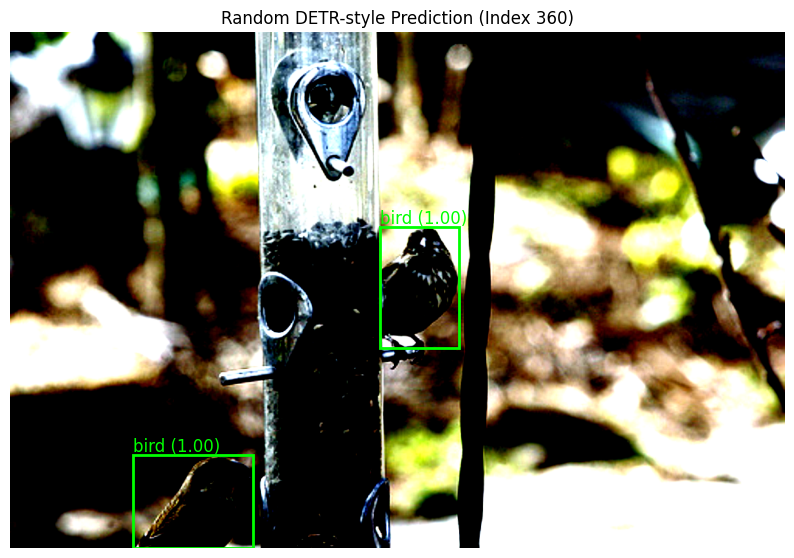

In [35]:
show_random_prediction(dataset, model, VOC_CLASSES, device)

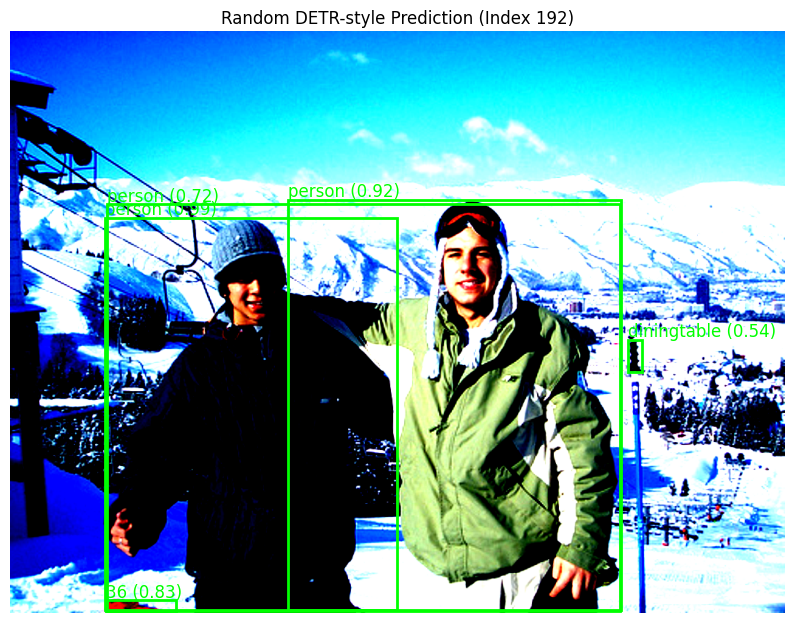

In [36]:
show_random_prediction(dataset, model, VOC_CLASSES, device)

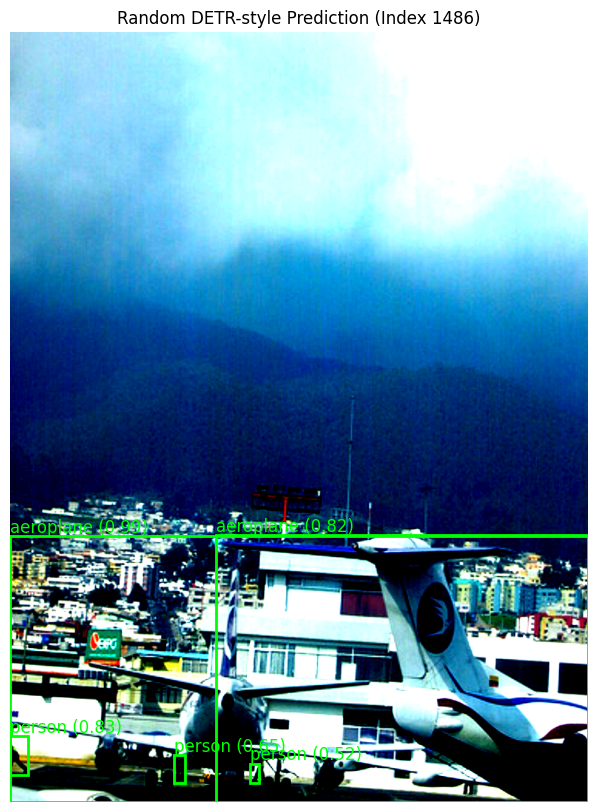

In [54]:
show_random_prediction(dataset, model, VOC_CLASSES, device)

In [40]:
with torch.no_grad():
    out = model([img.to(device)])
    print(type(out))
    print(out)


<class 'dict'>
{'pred_logits': tensor([[[-17.7375,   4.4588,  -5.5996,  ..., -11.6927,  -7.3055,  10.4563],
         [-18.7993,  -2.3846,  -4.9112,  ..., -10.9216,  -9.2306,  11.6899],
         [-17.5828,   4.7462,  -5.7546,  ..., -11.7914,  -7.4560,  10.4890],
         ...,
         [-18.5330,  -2.4468,  -6.8635,  ..., -11.0367,  -8.6010,  11.6033],
         [-19.4163,  -1.5407,  -4.8246,  ..., -11.6727,  -8.7012,  11.3994],
         [-18.8440,  -2.4416,  -6.7782,  ..., -11.4226,  -8.1038,  11.1968]]],
       device='cuda:0'), 'pred_boxes': tensor([[[0.1919, 0.4468, 0.0153, 0.0277],
         [0.5268, 0.4695, 0.7643, 0.2968],
         [0.1907, 0.4433, 0.0154, 0.0281],
         [0.5557, 0.5104, 0.7146, 0.3354],
         [0.9683, 0.9824, 0.0635, 0.0362],
         [0.4983, 0.3537, 0.8341, 0.4543],
         [0.5011, 0.3488, 0.8517, 0.4243],
         [0.4903, 0.3519, 0.8277, 0.4327],
         [0.5005, 0.5085, 0.8160, 0.3499],
         [0.1575, 0.4192, 0.0189, 0.0191],
         [0.4736, 0.35